In [1]:
from google.colab import drive

In [3]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
print("Drive Connected Successfully!")

Drive Connected Successfully!


In [5]:
import os
path = '/content/drive/MyDrive/SkillCraft_Internship/Task01/dataset/'
files = os.listdir(path)
print("Files found:", files)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/SkillCraft_Internship/Task01/dataset/'

In [6]:
import os
path = '/content/drive/MyDrive/house-prices-advanced-regression-techniques'
files = os.listdir(path)
print("Files found:", files)

Files found: ['sample_submission.csv', 'data_description.txt', 'train.csv', 'test.csv']


In [7]:
# Run this cell first
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

print("All libraries imported successfully!")

All libraries imported successfully!


In [12]:

df = pd.read_csv('/content/drive/MyDrive/house-prices-advanced-regression-techniques/train.csv')

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (1460, 81)

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [13]:
# All column names
print("All columns:")
print(df.columns.tolist())

# Data types
print("\nData types:")
print(df.dtypes)

# Basic statistics
print("\nBasic Statistics:")
df.describe()

All columns:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolAr

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Columns with missing values:
LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


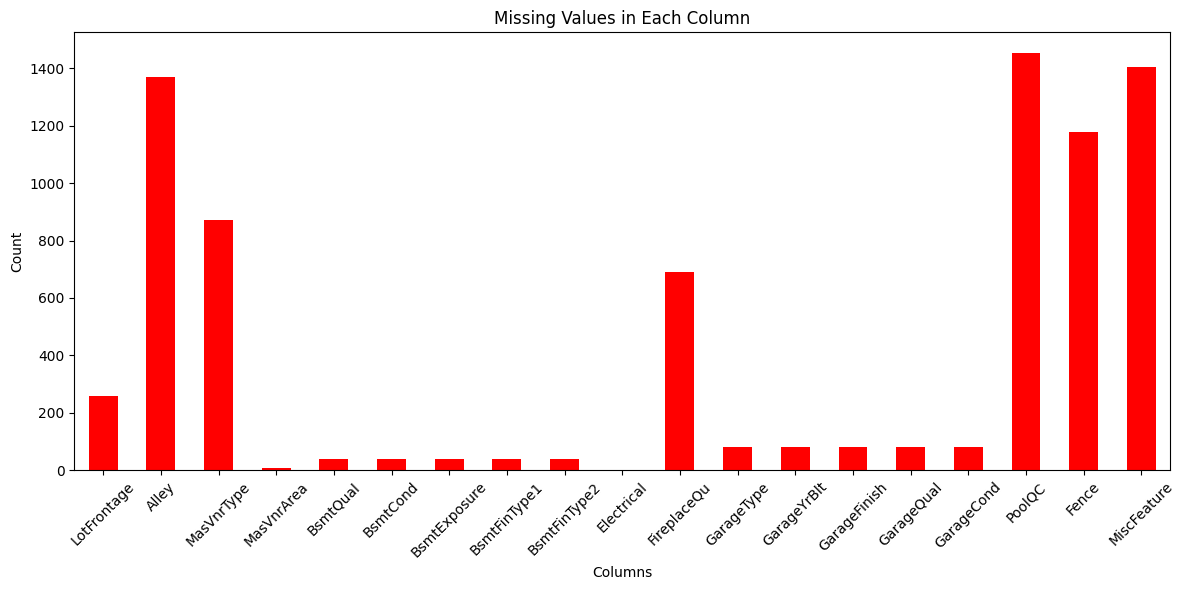

In [14]:
# Check which columns have missing values
missing = df.isnull().sum()
missing_cols = missing[missing > 0]

print("Columns with missing values:")
print(missing_cols)

# Visualize missing values
plt.figure(figsize=(12,6))
missing_cols.plot(kind='bar', color='red')
plt.title('Missing Values in Each Column')
plt.xlabel('Columns')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

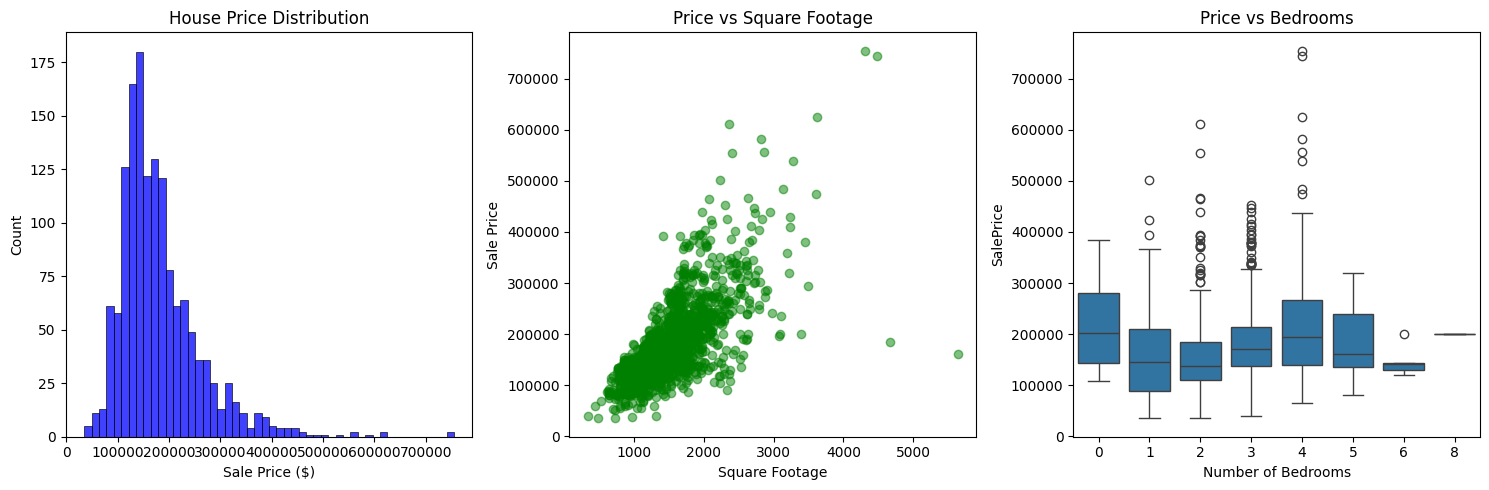

In [15]:
plt.figure(figsize=(15,5))

# Plot 1: Price distribution
plt.subplot(1,3,1)
sns.histplot(df['SalePrice'], bins=50, color='blue')
plt.title('House Price Distribution')
plt.xlabel('Sale Price ($)')

# Plot 2: Price vs Square Footage
plt.subplot(1,3,2)
plt.scatter(df['GrLivArea'], df['SalePrice'],
            alpha=0.5, color='green')
plt.title('Price vs Square Footage')
plt.xlabel('Square Footage')
plt.ylabel('Sale Price')

# Plot 3: Price vs Bedrooms
plt.subplot(1,3,3)
sns.boxplot(x='BedroomAbvGr', y='SalePrice', data=df)
plt.title('Price vs Bedrooms')
plt.xlabel('Number of Bedrooms')

plt.tight_layout()
plt.show()

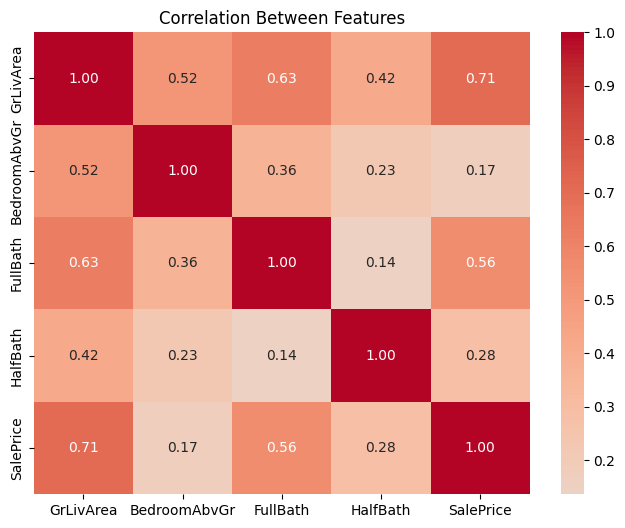


Correlation with Sale Price:
SalePrice       1.000000
GrLivArea       0.708624
FullBath        0.560664
HalfBath        0.284108
BedroomAbvGr    0.168213
Name: SalePrice, dtype: float64


In [16]:
# Select our main features
features_to_check = ['GrLivArea', 'BedroomAbvGr',
                     'FullBath', 'HalfBath', 'SalePrice']

# Correlation matrix
corr_matrix = df[features_to_check].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0)
plt.title('Correlation Between Features')
plt.show()

# Higher value = stronger relationship with price
print("\nCorrelation with Sale Price:")
print(corr_matrix['SalePrice'].sort_values(ascending=False))

In [17]:
# We use these 4 features as input
# as per task requirement
selected_features = ['GrLivArea',      # Square footage
                     'BedroomAbvGr',   # Bedrooms
                     'FullBath',       # Full bathrooms
                     'HalfBath']       # Half bathrooms

# X = input features
X = df[selected_features]

# y = target (what we want to predict)
y = df['SalePrice']

print("Input features shape:", X.shape)
print("Target shape:", y.shape)
print("\nSample X data:")
print(X.head())
print("\nSample y data:")
print(y.head())

Input features shape: (1460, 4)
Target shape: (1460,)

Sample X data:
   GrLivArea  BedroomAbvGr  FullBath  HalfBath
0       1710             3         2         1
1       1262             3         2         0
2       1786             3         2         1
3       1717             3         1         0
4       2198             4         2         1

Sample y data:
0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


In [18]:
# Check missing values in selected features
print("Missing values before:")
print(X.isnull().sum())

# Fill missing values with column mean
X = X.fillna(X.mean())

# Verify
print("\nMissing values after:")
print(X.isnull().sum())
# Should show all zeros now

Missing values before:
GrLivArea       0
BedroomAbvGr    0
FullBath        0
HalfBath        0
dtype: int64

Missing values after:
GrLivArea       0
BedroomAbvGr    0
FullBath        0
HalfBath        0
dtype: int64


In [19]:
# Scaling makes all features same range
# So model doesn't get confused by large numbers
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert back to dataframe for readability
X_scaled = pd.DataFrame(X_scaled, columns=selected_features)

print("Before scaling:")
print(X.describe())

print("\nAfter scaling:")
print(X_scaled.describe())
# Mean should be ~0, std should be ~1

Before scaling:
         GrLivArea  BedroomAbvGr     FullBath     HalfBath
count  1460.000000   1460.000000  1460.000000  1460.000000
mean   1515.463699      2.866438     1.565068     0.382877
std     525.480383      0.815778     0.550916     0.502885
min     334.000000      0.000000     0.000000     0.000000
25%    1129.500000      2.000000     1.000000     0.000000
50%    1464.000000      3.000000     2.000000     0.000000
75%    1776.750000      3.000000     2.000000     1.000000
max    5642.000000      8.000000     3.000000     2.000000

After scaling:
          GrLivArea  BedroomAbvGr      FullBath      HalfBath
count  1.460000e+03  1.460000e+03  1.460000e+03  1.460000e+03
mean  -1.277517e-16  2.141362e-16  1.180182e-16  2.083569e-17
std    1.000343e+00  1.000343e+00  1.000343e+00  1.000343e+00
min   -2.249120e+00 -3.514952e+00 -2.841822e+00 -7.616207e-01
25%   -7.347485e-01 -1.062465e+00 -1.026041e+00 -7.616207e-01
50%   -9.797004e-02  1.637791e-01  7.897405e-01 -7.616207e-01
75%

In [22]:
# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,    # Input features
    y,           # Target prices
    test_size=0.2,      # 20% for testing
    random_state=42     # For reproducibility
)

print("="*40)
print("DATA SPLIT SUMMARY")
print("="*40)
print(f"Total data:       {len(X_scaled)} houses")
print(f"Training data:    {len(X_train)} houses (80%)")
print(f"Testing data:     {len(X_test)} houses (20%)")
print("="*40)

# Visual explanation
print("\nWhat this means:")
print("→ Model LEARNS from 1168 houses")
print("→ Model is TESTED on 292 houses it never saw")

DATA SPLIT SUMMARY
Total data:       1460 houses
Training data:    1168 houses (80%)
Testing data:     292 houses (20%)

What this means:
→ Model LEARNS from 1168 houses
→ Model is TESTED on 292 houses it never saw


In [23]:
# Create Linear Regression model
model = LinearRegression()

print("Training started...")
print("Model is learning patterns from 1168 houses...")

# THIS IS THE TRAINING STEP
# Model looks at square footage, bedrooms, bathrooms
# and learns how they relate to price
model.fit(X_train, y_train)

print("\n" + "="*40)
print("TRAINING COMPLETE!")
print("="*40)

# See what model learned
print("\nWhat model learned (Coefficients):")
for feature, coef in zip(selected_features, model.coef_):
    print(f"  {feature}: ${coef:,.2f}")

print(f"\nBase price (Intercept): ${model.intercept_:,.2f}")

Training started...
Model is learning patterns from 1168 houses...

TRAINING COMPLETE!

What model learned (Coefficients):
  GrLivArea: $53,440.16
  BedroomAbvGr: $-21,777.09
  FullBath: $16,988.85
  HalfBath: $2,318.34

Base price (Intercept): $180,502.22


In [24]:
# Predict prices for test houses
y_pred = model.predict(X_test)

# Compare actual vs predicted
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred.round(2),
    'Difference': (y_test.values - y_pred).round(2)
})

print("Sample Predictions:")
print(results.head(10))

Sample Predictions:
   Actual Price  Predicted Price  Difference
0        154500        112217.02    42282.98
1        325000        305769.11    19230.89
2        115000        134851.73   -19851.73
3        159000        203697.66   -44697.66
4        315500        225925.44    89574.56
5         75500        121066.18   -45566.18
6        311500        206963.72   104536.28
7        146000        187148.93   -41148.93
8         84500        121066.18   -36566.18
9        135500        149891.75   -14391.75


In [25]:
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("="*45)
print("MODEL PERFORMANCE REPORT")
print("="*45)
print(f"MAE  (Mean Absolute Error):  ${mae:,.2f}")
print(f"RMSE (Root Mean Sq Error):   ${rmse:,.2f}")
print(f"R²   (Accuracy Score):        {r2:.4f}")
print("="*45)

print("\nWhat these mean:")
print(f"→ On average, prediction is off by ${mae:,.2f}")
print(f"→ R² of {r2:.2f} means model explains")
print(f"  {r2*100:.1f}% of price variation")

# R2 interpretation
if r2 >= 0.8:
    print("→ Model Performance: EXCELLENT ✅")
elif r2 >= 0.6:
    print("→ Model Performance: GOOD ✅")
elif r2 >= 0.4:
    print("→ Model Performance: AVERAGE ⚠️")
else:
    print("→ Model Performance: POOR ❌")

MODEL PERFORMANCE REPORT
MAE  (Mean Absolute Error):  $36,018.56
RMSE (Root Mean Sq Error):   $53,018.33
R²   (Accuracy Score):        0.6335

What these mean:
→ On average, prediction is off by $36,018.56
→ R² of 0.63 means model explains
  63.4% of price variation
→ Model Performance: GOOD ✅


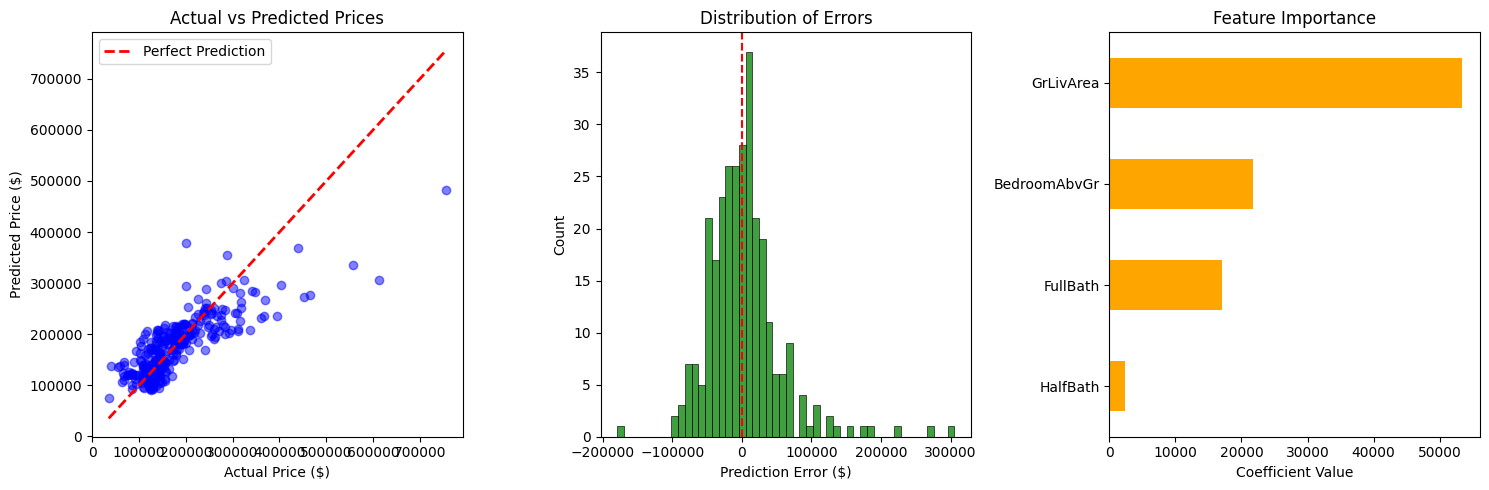

In [26]:
plt.figure(figsize=(15,5))

# Plot 1: Actual vs Predicted
plt.subplot(1,3,1)
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted Prices')
plt.legend()

# Plot 2: Residuals
residuals = y_test - y_pred
plt.subplot(1,3,2)
sns.histplot(residuals, bins=50, color='green')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Prediction Error ($)')
plt.title('Distribution of Errors')

# Plot 3: Feature Importance
plt.subplot(1,3,3)
feature_importance = pd.Series(
    np.abs(model.coef_),
    index=selected_features
)
feature_importance.sort_values().plot(
    kind='barh', color='orange'
)
plt.title('Feature Importance')
plt.xlabel('Coefficient Value')

plt.tight_layout()
plt.show()

In [27]:
def predict_house_price(sqft, bedrooms, fullbath, halfbath):
    """
    Predict house price based on features
    """
    # Create input
    house = pd.DataFrame({
        'GrLivArea': [sqft],
        'BedroomAbvGr': [bedrooms],
        'FullBath': [fullbath],
        'HalfBath': [halfbath]
    })

    # Scale input
    house_scaled = scaler.transform(house)

    # Predict
    price = model.predict(house_scaled)[0]

    print("="*40)
    print("HOUSE PRICE PREDICTION")
    print("="*40)
    print(f"Square Footage : {sqft} sqft")
    print(f"Bedrooms       : {bedrooms}")
    print(f"Full Bathrooms : {fullbath}")
    print(f"Half Bathrooms : {halfbath}")
    print(f"Predicted Price: ${price:,.2f}")
    print("="*40)

    return price

# Test with different houses
predict_house_price(sqft=1500, bedrooms=3,
                    fullbath=2, halfbath=1)

predict_house_price(sqft=2500, bedrooms=4,
                    fullbath=3, halfbath=1)

predict_house_price(sqft=800,  bedrooms=2,
                    fullbath=1, halfbath=0)

HOUSE PRICE PREDICTION
Square Footage : 1500 sqft
Bedrooms       : 3
Full Bathrooms : 2
Half Bathrooms : 1
Predicted Price: $191,625.17
HOUSE PRICE PREDICTION
Square Footage : 2500 sqft
Bedrooms       : 4
Full Bathrooms : 3
Half Bathrooms : 1
Predicted Price: $297,501.75
HOUSE PRICE PREDICTION
Square Footage : 800 sqft
Bedrooms       : 2
Full Bathrooms : 1
Half Bathrooms : 0
Predicted Price: $111,656.70


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(111656.7046552121)

In [30]:
import joblib

# Use your existing folder where train.csv is
save_path = '/content/drive/MyDrive/house-prices-advanced-regression-techniques/train.csv'

# Save model
joblib.dump(model, save_path + 'linear_regression_model.pkl')

# Save scaler
joblib.dump(scaler, save_path + 'scaler.pkl')

print("Model saved successfully!")
print(f"Location: {save_path}")

Model saved successfully!
Location: /content/drive/MyDrive/house-prices-advanced-regression-techniques/train.csv
